# TT-23 — K-Means: Gom nhóm sản phẩm để sắp xếp lại kệ hàng siêu thị

In [4]:
import sys, os
sys.path.insert(0, '../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

import features
import cluster

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 20)
%matplotlib inline

## 1. Đọc và làm sạch dữ liệu giao dịch

4 bước làm sạch bắt buộc:
1. Loại hoá đơn huỷ (Invoice bắt đầu bằng `C`)
2. Loại `Quantity <= 0` và `Price <= 0`
3. Loại `StockCode` không phải sản phẩm thật (POST, M, BANK CHARGES, DOT, ADJUST, và các mã tương tự như C2, D, S, AMAZONFEE, TEST001/2, PADS, CRUK phát hiện khi khảo sát dữ liệu)
4. Loại dòng thiếu mô tả sản phẩm

In [5]:
df_raw = features.load_raw('../dataset/online_retail_II.xlsx') 
if isinstance(df_raw, dict):
    df_raw = pd.concat(df_raw.values(), ignore_index=True)

print(f"Tổng số dòng giao dịch thô: {len(df_raw):,}")
df_raw.head()

Tổng số dòng giao dịch thô: 1,067,371


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df_clean = features.clean_transactions(df_raw)

Số dòng ban đầu: 1,067,371
  - Loại hoá đơn huỷ (Invoice bắt đầu 'C'): -19,494 dòng
  - Loại Quantity <= 0 hoặc Price <= 0: -6,207 dòng
  - Loại StockCode không phải sản phẩm (POST, M, DOT, ...): -4,588 dòng
  - Loại dòng thiếu Description: -0 dòng
Số dòng còn lại sau làm sạch giao dịch: 1,037,082


## 2. Tổng hợp lên cấp sản phẩm — tạo 8 đặc trưng

Đơn vị phân tích chuyển từ **giao dịch** → **sản phẩm** (`StockCode`). Với mỗi sản phẩm, tính:
- `tong_so_luong`, `tong_doanh_thu`, `gia_trung_binh`
- `so_don_hang`, `so_khach_mua`, `do_lech_sl`
- `sl_moi_don` = số lượng trung bình mỗi đơn
- `ty_le_mua_lai` = số đơn hàng / số khách (đo mức độ khách quay lại mua)

Sản phẩm có dưới 5 đơn hàng bị loại vì không đủ dữ liệu để mô tả hành vi mua đáng tin cậy.

In [7]:
sp = features.build_product_features(df_clean)
sp[features.FEATURE_COLS].describe()

Số sản phẩm (StockCode) trước tổng hợp: 4,732
Loại sản phẩm có < 5 đơn hàng: -335
Số sản phẩm còn lại để gom cụm: 4,397


,tong_so_luong,tong_doanh_thu,gia_trung_binh,so_don_hang,so_khach_mua,do_lech_sl,sl_moi_don,ty_le_mua_lai
count,4397.000000,4397.000000,4397.000000,4397.000000,4397.000000,4397.000000,4397.000000,4397.000000
mean,2570.128724,4530.074758,4.093110,225.463498,109.267455,31.662236,12.524717,2.087474
std,6086.964650,11590.973787,7.788467,343.402091,136.587026,149.186114,47.438506,1.670925
min,5.000000,3.780000,0.049600,5.000000,0.000000,0.000000,1.000000,1.000000
25%,185.000000,418.120000,1.391650,34.000000,19.000000,4.341997,3.495726,1.400000
50%,785.000000,1334.490000,2.490000,105.000000,58.000000,11.121311,6.621160,1.725490
75%,2380.000000,3988.980000,4.544136,266.000000,145.000000,23.694706,11.507519,2.273504
max,110138.000000,344563.250000,214.864865,5464.000000,1490.000000,4692.895055,2447.200000,48.000000


## 3. Vẽ histogram TRƯỚC và SAU log1p → chứng minh cần biến đổi

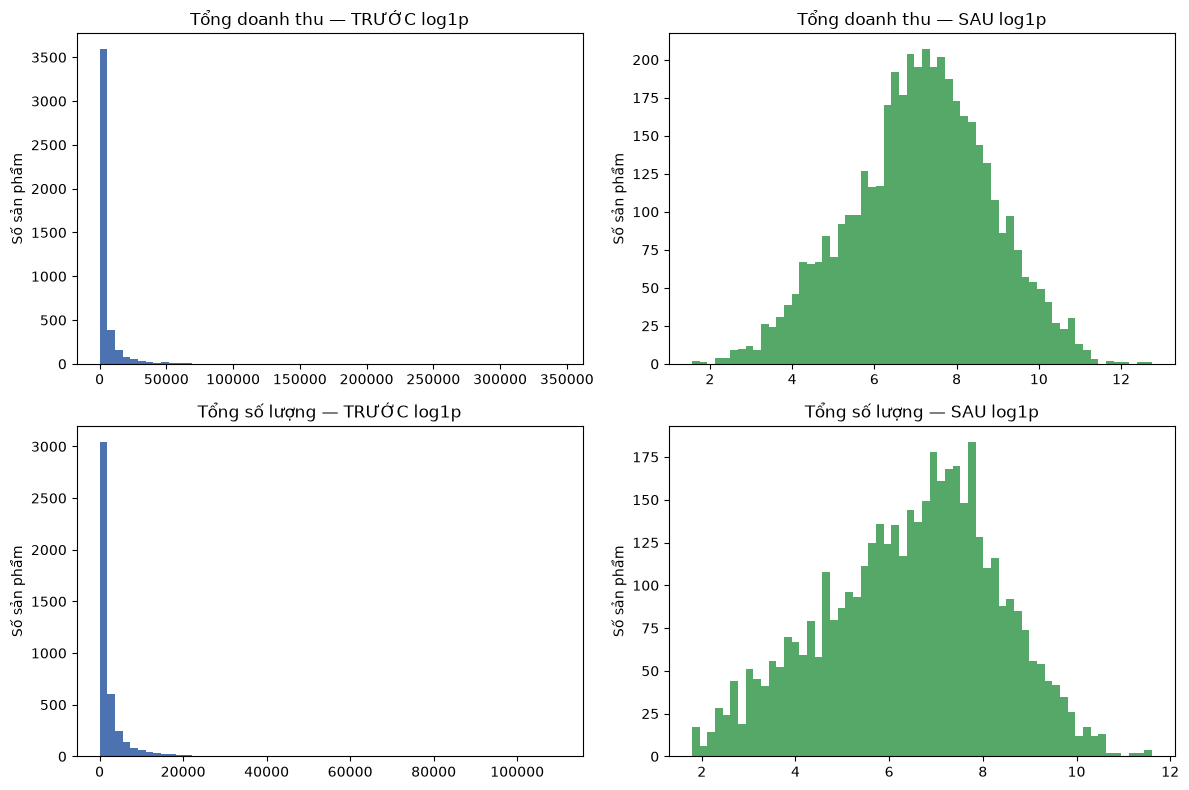

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].hist(sp['tong_doanh_thu'], bins=60, color='#4C72B0')
axes[0,0].set_title('Tổng doanh thu — TRƯỚC log1p')
axes[0,1].hist(np.log1p(sp['tong_doanh_thu']), bins=60, color='#55A868')
axes[0,1].set_title('Tổng doanh thu — SAU log1p')
axes[1,0].hist(sp['tong_so_luong'], bins=60, color='#4C72B0')
axes[1,0].set_title('Tổng số lượng — TRƯỚC log1p')
axes[1,1].hist(np.log1p(sp['tong_so_luong']), bins=60, color='#55A868')
axes[1,1].set_title('Tổng số lượng — SAU log1p')
for ax in axes.flat:
    ax.set_ylabel('Số sản phẩm')
plt.tight_layout()
plt.savefig('../reports/truoc_sau_log.png', dpi=120)
plt.show()

**Nhận xét:** phân phối trước log1p tập trung sát 0 với đuôi rất dài (vài sản phẩm bán hàng chục nghìn đơn vị). Sau log1p, phân phối gần đối xứng hơn nhiều — phù hợp hơn để đưa vào K-Means.

## 4.  Chạy K từ 2..12, ghi inertia + silhouette

Pipeline: `log1p` → `StandardScaler` → `KMeans`.

Chạy K từ 2 đến 12, ghi lại inertia và silhouette score cho mỗi K.

In [9]:
pipe = cluster.make_preprocess_pipeline()
X = sp[features.FEATURE_COLS].values
X_scaled = pipe.fit_transform(X)

scan = cluster.scan_k(X_scaled, range(2, 13))
scan

,K,inertia,silhouette
0,2,22320.954367,0.334508
1,3,18485.871608,0.257128
2,4,15810.104461,0.239521
3,5,13877.606244,0.248190
4,6,12438.701770,0.244149
5,7,11207.597282,0.236126
6,8,10339.424482,0.229791
7,9,9659.995334,0.233392
8,10,9156.839255,0.225994
9,11,8698.897687,0.212102


## 5: Vẽ Elbow + Silhouette cạnh nhau, CHỌN K có lý do (cả kỹ thuật lẫn kinh doanh)

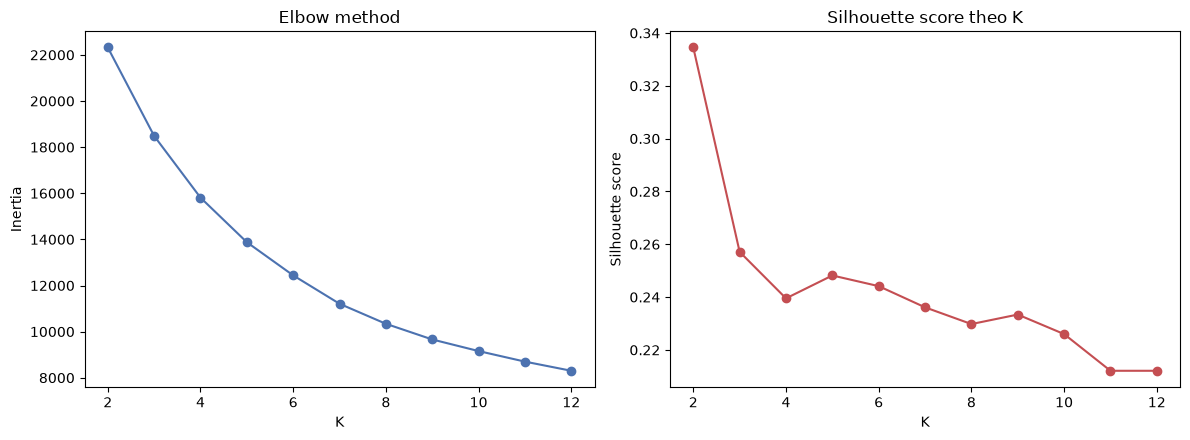

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(scan['K'], scan['inertia'], marker='o', color='#4C72B0')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow method')

axes[1].plot(scan['K'], scan['silhouette'], marker='o', color='#C44E52')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette score'); axes[1].set_title('Silhouette score theo K')
plt.tight_layout()
plt.savefig('../reports/elbow_silhouette.png', dpi=120)
plt.show()

**Chọn K = 5**, với căn cứ kép:

- **Kỹ thuật:** trong khoảng kinh doanh chấp nhận được (K = 4–6), K=5 đạt silhouette cao nhất (~0.248), cao hơn K=4 (~0.240) và K=6 (~0.244). Đường Elbow không có khuỷu tay rõ rệt (đặc trưng thường gặp với dữ liệu hành vi thực tế lệch phức tạp), nên silhouette là căn cứ kỹ thuật chính.
- **Kinh doanh:** siêu thị không thể quản lý & triển khai trưng bày cho quá nhiều nhóm (>6). K=5 vừa đủ chi tiết để phân biệt hành vi, vừa khả thi để bộ phận trưng bày triển khai.

## 6.  Kiểm tra `n_init`: chạy K-Means với n_init=1 và seed khác nhau
        → kết quả có ĐỔI không? → giải thích vì sao cần n_init=10

So sánh `n_init=1` (chỉ chạy 1 lần với mỗi seed) và `n_init=10` (lấy nghiệm tốt nhất trong 10 lần chạy) tại K=5, với 5 seed ngẫu nhiên khác nhau.

In [11]:
exp = cluster.n_init_experiment(X_scaled, k=5, seeds=range(5))
exp

,seed,n_init,inertia,silhouette
0,0,1,13877.807690,0.247404
1,0,10,13877.777946,0.247356
2,1,1,14370.529373,0.225927
3,1,10,13877.565531,0.248072
4,2,1,14370.576266,0.225941
5,2,10,13877.787113,0.247404
6,3,1,14314.557224,0.222055
7,3,10,13877.505183,0.248096
8,4,1,14370.590462,0.225871
9,4,10,13877.460028,0.247847


In [12]:
print("n_init=1  -> độ lệch chuẩn inertia:", exp[exp.n_init==1]['inertia'].std().round(2),
      "| độ lệch chuẩn silhouette:", exp[exp.n_init==1]['silhouette'].std().round(4))
print("n_init=10 -> độ lệch chuẩn inertia:", exp[exp.n_init==10]['inertia'].std().round(2),
      "| độ lệch chuẩn silhouette:", exp[exp.n_init==10]['silhouette'].std().round(4))

n_init=1  -> độ lệch chuẩn inertia: 215.48 | độ lệch chuẩn silhouette: 0.0102
n_init=10 -> độ lệch chuẩn inertia: 0.15 | độ lệch chuẩn silhouette: 0.0004


In [13]:
km, labels = cluster.fit_final_kmeans(X_scaled, k=5)
sp['cum'] = labels

coords, pca = cluster.pca_2d(X_scaled)
print('Phương sai giải thích bởi PC1, PC2:', pca.explained_variance_ratio_.round(3),
      '-> tổng:', pca.explained_variance_ratio_.sum().round(3))

Phương sai giải thích bởi PC1, PC2: [0.542 0.235] -> tổng: 0.777


## 7. PCA 2 chiều để vẽ scatter tô màu theo cụm

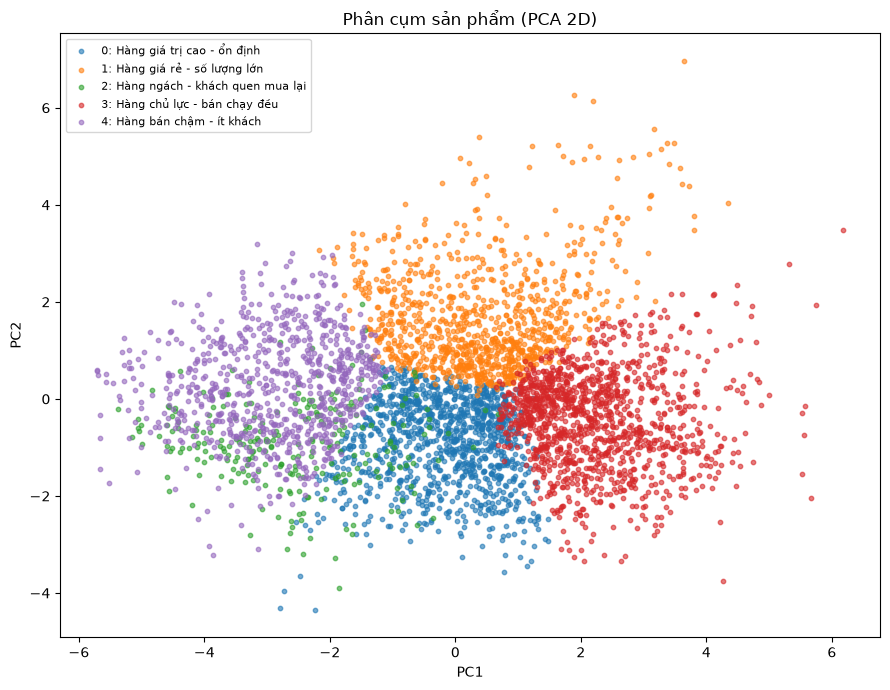

In [14]:
TEN_CUM = {
    3: 'Hàng chủ lực - bán chạy đều',
    0: 'Hàng giá trị cao - ổn định',
    1: 'Hàng giá rẻ - số lượng lớn',
    2: 'Hàng ngách - khách quen mua lại',
    4: 'Hàng bán chậm - ít khách',
}
sp['ten_cum'] = sp['cum'].map(TEN_CUM)

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for c in sorted(sp['cum'].unique()):
    mask = sp['cum'] == c
    ax.scatter(coords[mask, 0], coords[mask, 1], s=10, alpha=0.6,
               label=f'{c}: {TEN_CUM[c]}', color=colors[c])
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Phân cụm sản phẩm (PCA 2D)')
ax.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.savefig('../reports/pca_scatter.png', dpi=120)
plt.show()

## 8 + 9. Bảng mô tả và đặt tên cụm

| Cụm | Tên | Đặc điểm | Đề xuất trưng bày |
|---|---|---|---|
| 3 | **Hàng chủ lực – bán chạy đều** | Nhiều mã hàng nhất, chiếm ~77% doanh thu, giá thấp-vừa, số đơn/khách mua rất cao | Vị trí trung tâm, đầu lối đi chính, tầm mắt |
| 0 | **Hàng giá trị cao – ổn định** | Giá trung bình cao nhất, doanh thu/mã hàng cao, bán đều đặn | Khu trưng bày nổi bật, đầu kệ, ánh sáng tốt |
| 1 | **Hàng giá rẻ – số lượng lớn** | Giá thấp nhất, số lượng bán/đơn cao, doanh thu/mã hàng thấp | Kệ thấp dễ lấy số lượng lớn, gần lối ra |
| 2 | **Hàng ngách – khách quen mua lại** | Ít mã hàng nhất, tỷ lệ mua lại cao vượt trội (khách quay lại nhiều lần) | Khu ưu đãi thành viên / gần quầy thu ngân để nhắc khách quen |
| 4 | **Hàng bán chậm – ít khách** | Số đơn và số khách thấp nhất, doanh thu đóng góp không đáng kể | Góc khuất kệ, cân nhắc thanh lý / khuyến mãi đẩy hàng |

In [15]:
desc = cluster.describe_clusters(sp)
desc['ten_cum'] = desc['cum'].map(TEN_CUM)
desc

,cum,so_ma_hang,doanh_thu,gia_tb,don_hang_tb,ty_le_mua_lai_tb,ty_le_doanh_thu_%,ten_cum
0,3,1237,15259577.93,2.394402,581.510914,2.147892,76.6,Hàng chủ lực - bán chạy đều
1,0,1144,3386663.07,6.743466,152.303322,1.838315,17.0,Hàng giá trị cao - ổn định
2,1,960,968517.33,1.745115,71.092708,1.618055,4.9,Hàng giá rẻ - số lượng lớn
3,4,798,190090.65,5.706032,20.134085,1.585169,1.0,Hàng bán chậm - ít khách
4,2,258,113889.73,4.233637,52.259690,6.202903,0.6,Hàng ngách - khách quen mua lại


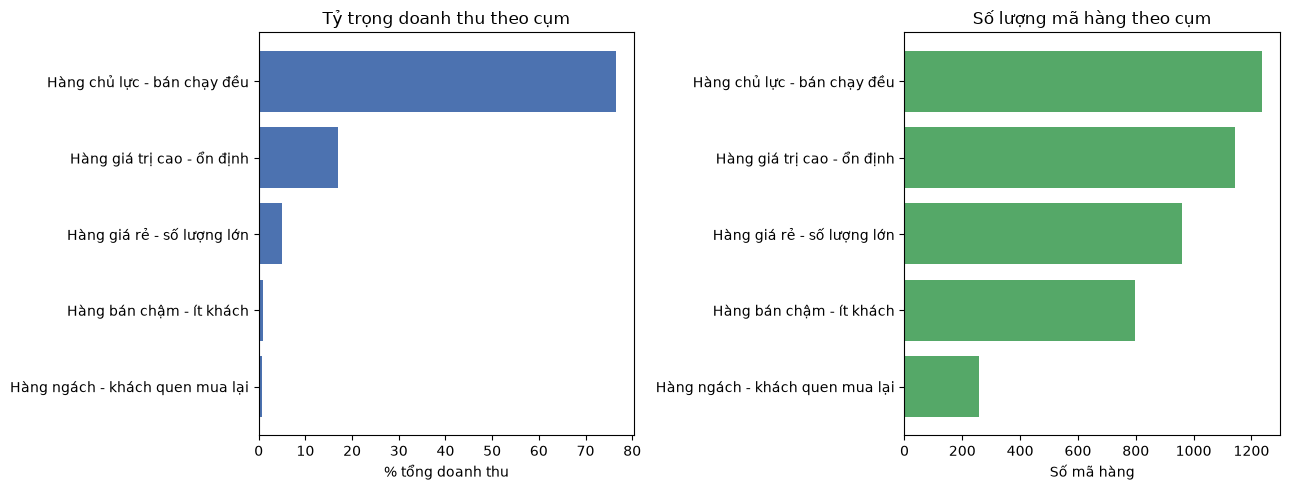

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = desc.sort_values('ty_le_doanh_thu_%', ascending=True)
axes[0].barh(order['ten_cum'], order['ty_le_doanh_thu_%'], color='#4C72B0')
axes[0].set_xlabel('% tổng doanh thu'); axes[0].set_title('Tỷ trọng doanh thu theo cụm')

order2 = desc.sort_values('so_ma_hang', ascending=True)
axes[1].barh(order2['ten_cum'], order2['so_ma_hang'], color='#55A868')
axes[1].set_xlabel('Số mã hàng'); axes[1].set_title('Số lượng mã hàng theo cụm')
plt.tight_layout()
plt.savefig('../reports/mo_ta_cum.png', dpi=120)
plt.show()

## 10. So sánh với DBSCAN

DBSCAN không cần biết trước số cụm K, và tự động đánh dấu các điểm "nhiễu" (không thuộc cụm nào rõ ràng) — hữu ích để kiểm tra xem giả định "mọi sản phẩm đều thuộc 1 trong K nhóm hình cầu" của K-Means có hợp lý không.

In [17]:
db_labels, n_clusters_db, n_noise = cluster.run_dbscan(X_scaled, eps=0.8, min_samples=10)
sp['dbscan_cum'] = db_labels
sp['dbscan_la_nhieu'] = db_labels == -1

print(f"DBSCAN tìm ra {n_clusters_db} cụm mật độ")
print(f"Số sản phẩm bị đánh dấu là NHIỄU (sản phẩm cá biệt): {n_noise:,} / {len(sp):,} ({n_noise/len(sp)*100:.1f}%)")

DBSCAN tìm ra 3 cụm mật độ
Số sản phẩm bị đánh dấu là NHIỄU (sản phẩm cá biệt): 490 / 4,397 (11.1%)


## 11.  Xuất file bàn giao: StockCode | Description | cụm | tên cụm

In [18]:
ban_giao = sp[['StockCode', 'Mo_ta', 'cum', 'ten_cum']].rename(columns={
    'Mo_ta': 'Description', 'cum': 'Ma_cum', 'ten_cum': 'Ten_cum'
})
ban_giao.to_csv('../outputs/san_pham_theo_cum.csv', index=False, encoding='utf-8-sig')
print(f"Đã xuất {len(ban_giao):,} dòng ra outputs/san_pham_theo_cum.csv")
ban_giao.head(10)

Đã xuất 4,397 dòng ra outputs/san_pham_theo_cum.csv


,StockCode,Description,Ma_cum,Ten_cum
0,10002,INFLATABLE POLITICAL GLOBE,3,Hàng chủ lực - bán chạy đều
1,10080,GROOVY CACTUS INFLATABLE,1,Hàng giá rẻ - số lượng lớn
2,10120,DOGGY RUBBER,1,Hàng giá rẻ - số lượng lớn
3,10123C,HEARTS WRAPPING TAPE,1,Hàng giá rẻ - số lượng lớn
4,10123G,ARMY CAMO WRAPPING TAPE,1,Hàng giá rẻ - số lượng lớn
5,10124A,SPOTS ON RED BOOKCOVER TAPE,4,Hàng bán chậm - ít khách
6,10124G,ARMY CAMO BOOKCOVER TAPE,4,Hàng bán chậm - ít khách
7,10125,MINI FUNKY DESIGN TAPES,1,Hàng giá rẻ - số lượng lớn
8,10133,COLOURING PENCILS BROWN TUBE,3,Hàng chủ lực - bán chạy đều
9,10134,COLOURING PENCILS BROWN TUBE,1,Hàng giá rẻ - số lượng lớn
